## Run Simulated Defense

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import optuna
import jax
import jax.numpy as jnp
import optuna
import json
from functools import partial
from jax import jit, vmap, vmap
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

In [3]:
import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))

from src.gradient_flows.potentials import params as default_params
from src.gradient_flows.viz_tools import run_simulation, create_interactive_plot, plot_speed_analysis

In [ ]:
%load_ext autoreload
%autoreload 2

## Run Functions

In [5]:
df = pd.read_parquet("../data/processed/traj_features/traj_01.18.2016.GSW.at.CLE_21500622.parquet")
df = df.drop(index=[29, 84], errors='ignore')
df = df.reset_index(drop=True)

In [7]:
df.columns

Index(['GAME_ID', 'SHOT_EVENT_ID', 'tracking_event_id', 'event_list_idx',
       'PERIOD', 'game_clock', 'PLAYER_ID', 'TEAM_ID', 'flipped_coordinates',
       'ball_x_traj', 'ball_y_traj', 'off1_pid', 'off1_x_traj', 'off1_y_traj',
       'off1_q_traj', 'def1_pid', 'def1_x_traj', 'def1_y_traj', 'off2_pid',
       'off2_x_traj', 'off2_y_traj', 'off2_q_traj', 'def2_pid', 'def2_x_traj',
       'def2_y_traj', 'off3_pid', 'off3_x_traj', 'off3_y_traj', 'off3_q_traj',
       'def3_pid', 'def3_x_traj', 'def3_y_traj', 'off4_pid', 'off4_x_traj',
       'off4_y_traj', 'off4_q_traj', 'def4_pid', 'def4_x_traj', 'def4_y_traj',
       'off5_pid', 'off5_x_traj', 'off5_y_traj', 'off5_q_traj', 'def5_pid',
       'def5_x_traj', 'def5_y_traj', 'release_frame_global_idx',
       'pbp_frame_global_idx', 'local_release_idx', 'local_pbp_idx',
       'ball_z_traj', 'SHOT_MADE_FLAG'],
      dtype='object')

In [6]:
STUDY_NAME = "nba-defensive-optimization"
STORAGE_NAME = f"sqlite:///{STUDY_NAME}.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_NAME)

'''target_trial_number = 1
best_trial = None
for trial in study.trials:
    if trial.number == target_trial_number:
        best_trial = trial
        break'''
solver_params = {
    **default_params,
    'jko_lambda': 0.5,
    'sinkhorn_epsilon': 0.01,
    'learning_rate': 0.1, # Default learning rate
    'velocity_cap': 0.8,
    'court_dims': [[0., 94.], [0., 50.]],
    'max_gradient_norm': 1.0,
    'acceleration_penalty_weight': 2.0,
    'velocity_penalty_weight': 1.0,
    }


best_trial = min(study.best_trials, key=lambda t: t.values[0])
print(f"Using parameters from Trial #{best_trial.number} with values: {best_trial.values}")
# Update the solver_params with the learned values
solver_params.update(best_trial.params)

print(f"--- Loaded Trial {best_trial.number} ---")
print(f"Scores -> Pressure: {best_trial.values[0]:.3f}, Smoothness: {best_trial.values[1]:.3f}")

# 3. Apply the fixed IST params that weren't searched by Optuna
best_params = best_trial.params
best_params.update({
    'ist_q_exp': 2.1631, 
    'ist_o_exp': 1.0313,
    'jko_lambda': 0.5,
    'sinkhorn_epsilon': 0.01,
    'learning_rate': 0.1, # Default learning rate
    'velocity_cap': 0.8,
    'soft_velocity_cap': 0.6, # Soft limit (15 ft/s)
    'court_dims': [[0., 94.], [0., 50.]],
    'max_gradient_norm': 1.0,
    'acceleration_penalty_weight': 2.0,
    'velocity_penalty_weight': 1.0,     # Take massive steps (was 0.01)
})

Using parameters from Trial #49 with values: [53.439178466796875, 0.30132144689559937]
--- Loaded Trial 49 ---
Scores -> Pressure: 53.439, Smoothness: 0.301


In [ ]:
def get_court_shapes_plotly():
    """Returns standard NBA court lines for Plotly."""
    shapes = [
        dict(type="rect", x0=0, y0=0, x1=94, y1=50, line=dict(color="black", width=2)),
        dict(type="line", x0=47, y0=0, x1=47, y1=50, line=dict(color="black", width=2)),
        dict(type="circle", x0=4.5, y0=24.25, x1=6, y1=25.75, line=dict(color="black", width=2)),
        dict(type="circle", x0=94-6, y0=24.25, x1=94-4.5, y1=25.75, line=dict(color="black", width=2))
    ]
    r = 23.75
    shapes.extend([
        dict(type="path", path=f"M {r+5.25},47.5 A {r},{r} 0 0,0 {r+5.25},2.5", line=dict(color="black", width=2)),
        dict(type="path", path=f"M {94-(r+5.25)},47.5 A {r},{r} 0 0,1 {94-(r+5.25)},2.5", line=dict(color="black", width=2)),
        dict(type="line", x0=5.25, y0=2.5, x1=5.25+r, y1=2.5, line=dict(color="black", width=2)),
        dict(type="line", x0=5.25, y0=47.5, x1=5.25+r, y1=47.5, line=dict(color="black", width=2)),
        dict(type="line", x0=94-5.25, y0=2.5, x1=94-(r+5.25), y1=2.5, line=dict(color="black", width=2)),
        dict(type="line", x0=94-5.25, y0=47.5, x1=94-(r+5.25), y1=47.5, line=dict(color="black", width=2))
    ])
    return shapes

In [8]:
def animate_single_play(off_traj, def_traj, ball_traj, q_traj, d0=18.0, k=0.3, b_floor=0.4):
    """
    Takes pre-extracted trajectory arrays and returns an interactive 
    Plotly animation of the play with IST scores.
    
    Expected shapes:
    - off_traj, def_traj: (frames, 5, 2)
    - ball_traj: (frames, 2)
    - q_traj: (frames, 5)
    """
    pio.renderers.default = "browser" 
    
    num_frames = off_traj.shape[0]

    # --- 1. Calculate IST (Now Including Ball Distance) ---
    
    # A. Defender Openness
    dx = off_traj[:, :, None, 0] - def_traj[:, None, :, 0]
    dy = off_traj[:, :, None, 1] - def_traj[:, None, :, 1]
    distances_to_def = np.sqrt(dx**2 + dy**2)
    openness = np.min(distances_to_def, axis=2) # Nearest defender
    
    # B. Distance to Ball
    dx_ball = off_traj[:, :, 0] - ball_traj[:, None, 0]
    dy_ball = off_traj[:, :, 1] - ball_traj[:, None, 1]
    dist_to_ball = np.sqrt(dx_ball**2 + dy_ball**2)
    
    # Calculate raw decay, then compress it so it never drops below b_floor
    raw_logistic = 1.0 / (1.0 + np.exp(k * (dist_to_ball - d0)))
    b_factor = b_floor + (1.0 - b_floor) * raw_logistic
    
    # C. Final IST Calculation (Q * O * B)
    ist = (q_traj ** 2.16) * (openness ** 1.03) * b_factor

    # --- 2. Build Plotly Figure ---
    fig = go.Figure()

    def get_text_labels(ist_array):
        return [f"<b>{val:.2f}</b>" for val in ist_array]

    # Initial frame traces
    # Trace 0: Defense
    fig.add_trace(go.Scatter(x=def_traj[0, :, 0], y=def_traj[0, :, 1], mode='markers', 
                             marker=dict(color='blue', size=15), name='Defense'))
    # Trace 1: Offense
    fig.add_trace(go.Scatter(x=off_traj[0, :, 0], y=off_traj[0, :, 1], mode='markers+text', 
                             text=get_text_labels(ist[0]), textposition="top center", 
                             marker=dict(color='red', size=15), name='Offense'))
    # Trace 2: Ball
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', 
                             marker=dict(color='orange', size=12), name='Ball'))

    # Build animation frames (Added traces mapping for lag-free performance)
    frames = []
    for f in range(num_frames):
        frame_data = [
            go.Scatter(x=def_traj[f, :, 0], y=def_traj[f, :, 1]),
            go.Scatter(x=off_traj[f, :, 0], y=off_traj[f, :, 1], text=get_text_labels(ist[f])),
            go.Scatter(x=[ball_traj[f, 0]], y=[ball_traj[f, 1]])
        ]
        frames.append(go.Frame(data=frame_data, name=str(f), traces=[0, 1, 2]))
        
    fig.frames = frames

    # Animation layout and controls
    fig.update_layout(
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(label="Play", method="animate", 
                     args=[None, {"frame": {"duration": 50, "redraw": False}, 
                                  "fromcurrent": True, "transition": {"duration": 0}}]),
                dict(label="Pause", method="animate", 
                     args=[[None], {"frame": {"duration": 0, "redraw": False}, 
                                    "mode": "immediate", "transition": {"duration": 0}}])
            ]
        )],
        sliders=[dict(
            steps=[dict(method='animate', 
                        args=[[fr.name], dict(mode='immediate', frame=dict(duration=50, redraw=False), 
                                             transition=dict(duration=0))]) for fr in fig.frames],
            transition=dict(duration=0), x=0, xanchor="left", len=1,
        )],
        title_text="Play Animation with Ball Factor IST",
        shapes=get_court_shapes_plotly(),
        xaxis=dict(range=[0, 94], autorange=False, showgrid=False, zeroline=False),
        yaxis=dict(range=[0, 50], autorange=False, scaleanchor="x", scaleratio=1, showgrid=False, zeroline=False),
        plot_bgcolor="white",
        height=600, width=1000
    )
    
    return fig

In [9]:
def create_interactive_plot(sim_traj, real_traj, ball_traj, offenders_traj):
    """Creates an interactive Plotly figure comparing real vs. simulated defense."""
    pio.renderers.default = "browser"

    fig = make_subplots(rows=1, cols=2, subplot_titles=('Real Defense', 'Simulated (JKO)'))

    # Initial Traces (Exactly as you had them)
    fig.add_trace(go.Scatter(x=real_traj[0, :, 0], y=real_traj[0, :, 1], mode='markers', marker=dict(color='blue', size=15), name='Real Defenders'), row=1, col=1)
    fig.add_trace(go.Scatter(x=offenders_traj[0, :, 0], y=offenders_traj[0, :, 1], mode='markers', marker=dict(color='red', size=15), name='Offenders'), row=1, col=1)
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', marker=dict(color='orange', size=12), name='Ball'), row=1, col=1)
    
    fig.add_trace(go.Scatter(x=sim_traj[0, :, 0], y=sim_traj[0, :, 1], mode='markers', marker=dict(color='blue', size=15, opacity=0.6), name='Sim Defenders'), row=1, col=2)
    fig.add_trace(go.Scatter(x=offenders_traj[0, :, 0], y=offenders_traj[0, :, 1], mode='markers', marker=dict(color='red', size=15), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', marker=dict(color='orange', size=12), showlegend=False), row=1, col=2)

    # Create frames WITH explicit trace mapping to fix lag
    frames = []
    for k in range(len(sim_traj)):
        frames.append(go.Frame(
            data=[
                go.Scatter(x=real_traj[k, :, 0], y=real_traj[k, :, 1]),
                go.Scatter(x=offenders_traj[k, :, 0], y=offenders_traj[k, :, 1]),
                go.Scatter(x=[ball_traj[k, 0]], y=[ball_traj[k, 1]]),
                go.Scatter(x=sim_traj[k, :, 0], y=sim_traj[k, :, 1]),
                go.Scatter(x=offenders_traj[k, :, 0], y=offenders_traj[k, :, 1]),
                go.Scatter(x=[ball_traj[k, 0]], y=[ball_traj[k, 1]]),
            ],
            traces=[0, 1, 2, 3, 4, 5], # THIS is what prevents Plotly from lagging
            name=str(k)
        ))
    fig.frames = frames

    # Animation controls (redraw set to False for smoothness)
    fig.update_layout(
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 50, "redraw": False}, "fromcurrent": True, "transition": {"duration": 0}}])]
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name], dict(mode='immediate', frame=dict(duration=50, redraw=False), transition=dict(duration=0))]) for f in fig.frames],
            transition=dict(duration=0),
            x=0,
            xanchor="left",
            len=1,
        )]
    )

    # Dynamic Half-Court Logic
    start_x = ball_traj[0, 0]
    if start_x < 47:
        x_range = [0, 47]  # Left side of court
    else:
        x_range = [47, 94] # Right side of court

    # General layout
    court_shapes = get_court_shapes_plotly() # Assumes you have this imported
    fig.update_layout(
        title_text="Defensive Simulation vs. Reality",
        shapes=court_shapes
    )
    
    # Apply the half-court crop to both subplots
    fig.update_xaxes(range=x_range, autorange=False)
    fig.update_yaxes(range=[0, 50], autorange=False, scaleanchor="x1", scaleratio=1)

    return fig

In [10]:
def run_simulation_from_row(row, solver_params):
    # 1. Extract Data
    ball_traj = jnp.stack([jnp.array(row['ball_y_traj']) + 5.25, 
                           jnp.array(row['ball_x_traj']) + 25.0], axis=1)
    
    off_list, q_list, def_list = [], [], []
    for i in range(1, 6):
        off_list.append(jnp.stack([jnp.array(row[f'off{i}_y_traj']) + 5.25, 
                                   jnp.array(row[f'off{i}_x_traj']) + 25.0], axis=1))
        q_list.append(jnp.array(row[f'off{i}_q_traj']))
        def_list.append(jnp.stack([jnp.array(row[f'def{i}_y_traj']) + 5.25, 
                                   jnp.array(row[f'def{i}_x_traj']) + 25.0], axis=1))
        
    off_traj = jnp.stack(off_list, axis=1) 
    q_traj = jnp.stack(q_list, axis=1)     
    real_def_traj = jnp.stack(def_list, axis=1)

    # 2. Compute Weights
    ball_dist = jnp.linalg.norm(off_traj - ball_traj[:, None, :], axis=2)
    b_traj = 0.4 + 0.6 * (1.0 / (1.0 + jnp.exp(0.3 * (ball_dist - 18.0))))
    
    sim_weights = jnp.maximum((q_traj ** solver_params.get('ist_q_exp', 1.0)) * b_traj, 0.35)  
    
    # 3. Hoop Position
    basket_pos = jnp.array([5.25, 25.0]) if jnp.mean(real_def_traj[0, :, 0]) < 47.0 else jnp.array([88.75, 25.0])
        
    # 4. Run Simulation
    # Note: run_simulation returns L+1 frames. We slice it to length L to match off_traj.
    raw_sim_traj = run_simulation(real_def_traj[0], ball_traj, off_traj, sim_weights, basket_pos, solver_params)
    sim_def_traj = raw_sim_traj[:len(off_traj)] # FIX: Match lengths
    
    # 5. Display IST Calculation (Now shapes will match: (L, 5, 1, 2) - (L, 1, 5, 2))
    off_exp = off_traj[:, :, None, :]
    sim_dist = jnp.min(jnp.linalg.norm(off_exp - sim_def_traj[:, None, :, :], axis=-1), axis=2)
    real_dist = jnp.min(jnp.linalg.norm(off_exp - real_def_traj[:, None, :, :], axis=-1), axis=2)
    
    o_exp = solver_params.get('ist_o_exp', 1.0)
    ist_sim = sim_weights * (jnp.clip(sim_dist / 6.0, 0.5, 1.5) ** o_exp)
    ist_real = sim_weights * (jnp.clip(real_dist / 6.0, 0.5, 1.5) ** o_exp)
    
    return sim_def_traj, real_def_traj, ball_traj, ist_sim, ist_real, off_traj, basket_pos

In [11]:
def smooth_trajectory(traj, alpha=0.3):
    """
    Applies an Exponential Moving Average (EMA) to smooth out micro-jitters.
    Lower alpha = smoother, but very slightly delayed.
    """
    # Convert JAX array to standard NumPy array for easy processing
    traj = np.array(traj) 
    smoothed = np.zeros_like(traj)
    smoothed[0] = traj[0] 
    
    for t in range(1, len(traj)):
        smoothed[t] = alpha * traj[t] + (1 - alpha) * smoothed[t-1]
        
    return smoothed

In [12]:
def get_play_summary(row, params):
    """
    Calculates aggregate pressure statistics for a play.
    Compares the Real Defense against the JKO Simulated Defense.
    """
    # 1. Run the simulation
    res = run_simulation_from_row(row, params)
    sim_traj, real_traj, ball_traj, ist_sim, ist_real, off_traj, basket = res
    
    # 2. Identify the shot frame (the point of ball release)
    shot_frame = int(row['local_release_idx'])
    
    # 3. Mask the trajectories
    # We set IST to 0.0 after the shot is released so we only measure 
    # the defense's impact on the actual play.
    ist_sim_active = ist_sim.at[shot_frame:].set(0.0)
    ist_real_active = ist_real.at[shot_frame:].set(0.0)
    
    # 4. Calculate Aggregate Statistics
    # Total Pressure is the sum of all IST values across all 5 players and all frames
    total_real_pressure = float(jnp.sum(ist_real_active))
    total_sim_pressure = float(jnp.sum(ist_sim_active))
    
    # Pressure Saved (Positive means the Simulation was 'Better' / tighter)
    pressure_saved = total_real_pressure - total_sim_pressure
    pct_improvement = (pressure_saved / total_real_pressure) * 100 if total_real_pressure > 0 else 0
    
    return {
        "Play Index": row.name,
        "Total Real IST": round(total_real_pressure, 2),
        "Total Sim IST": round(total_sim_pressure, 2),
        "Pressure Prevented": round(pressure_saved, 2),
        "Efficiency Gain (%)": f"{pct_improvement:.1f}%",
        "Active Frames": shot_frame
    }

# --- Usage ---
play = df.iloc[74]
stats = get_play_summary(play, best_params)

print(f"--- Summary Statistics for Play {stats['Play Index']} ---")
for key, val in stats.items():
    print(f"{key}: {val}")

--- Summary Statistics for Play 74 ---
Play Index: 74
Total Real IST: nan
Total Sim IST: 289.0
Pressure Prevented: nan
Efficiency Gain (%): 0.0%
Active Frames: 75


In [13]:
def get_global_report(summary_df):
    # 1. Clean data (convert '15.4%' strings to floats if needed)
    if summary_df['Efficiency Gain (%)'].dtype == object:
        eff_floats = summary_df['Efficiency Gain (%)'].str.replace('%', '').astype(float)
    else:
        eff_floats = summary_df['Efficiency Gain (%)']
    
    # 2. Global Totals
    total_real_ist = summary_df['Total Real IST'].sum()
    total_sim_ist = summary_df['Total Sim IST'].sum()
    total_pressure_prevented = summary_df['Pressure Prevented'].sum()
    
    # 3. Overall Defensive Efficiency (The "Big Number")
    # This is better than averaging the percentages; it weights long plays more.
    global_efficiency = (total_pressure_prevented / total_real_ist) * 100 if total_real_ist > 0 else 0
    
    # 4. Play-Level Stats
    avg_gain = eff_floats.mean()
    median_gain = eff_floats.median()
    std_gain = eff_floats.std()
    
    # 5. Outlier Detection (Top 3 Defensive Lapses)
    top_3_lapses = summary_df.nlargest(3, 'Pressure Prevented')[['Play Index', 'Pressure Prevented', 'Efficiency Gain (%)']]

    print("==========================================")
    print("      GLOBAL DEFENSIVE ANALYSIS REPORT    ")
    print("==========================================")
    print(f"Total Plays Analyzed:        {len(summary_df)}")
    print(f"Total Real Pressure:        {total_real_ist:.2f}")
    print(f"Total Sim Pressure:         {total_sim_ist:.2f}")
    print(f"Total Pressure Prevented:   {total_pressure_prevented:.2f}")
    print(f"---")
    print(f"GLOBAL EFFICIENCY GAIN:     {global_efficiency:.2f}%")
    print(f"---")
    print(f"Avg Gain per Play:          {avg_gain:.2f}%")
    print(f"Median Gain per Play:       {median_gain:.2f}%")
    print(f"Consistency (Std Dev):      {std_gain:.2f}%")
    print("\nTOP 3 DEFENSIVE LAPSES (Highest Sim Improvement):")
    print(top_3_lapses.to_string(index=False))

# Run it
get_global_report(summary_df)

NameError: name 'summary_df' is not defined

In [ ]:
play = df.iloc[107]
shot_frame = play['local_release_idx']

sim_def_traj, real_def_traj, ball_traj, offender_weights_traj, offender_weights_traj_real, off_traj, basket_pos = run_simulation_from_row(play, best_params)
offender_weights_traj = offender_weights_traj.at[shot_frame:].set(0.1)

smoothed_sim_def_traj = smooth_trajectory(sim_def_traj, alpha=0.3)
animate_single_play(off_traj, smoothed_sim_def_traj, ball_traj, offender_weights_traj)

Saved speed analysis plot to speed_analysis.png


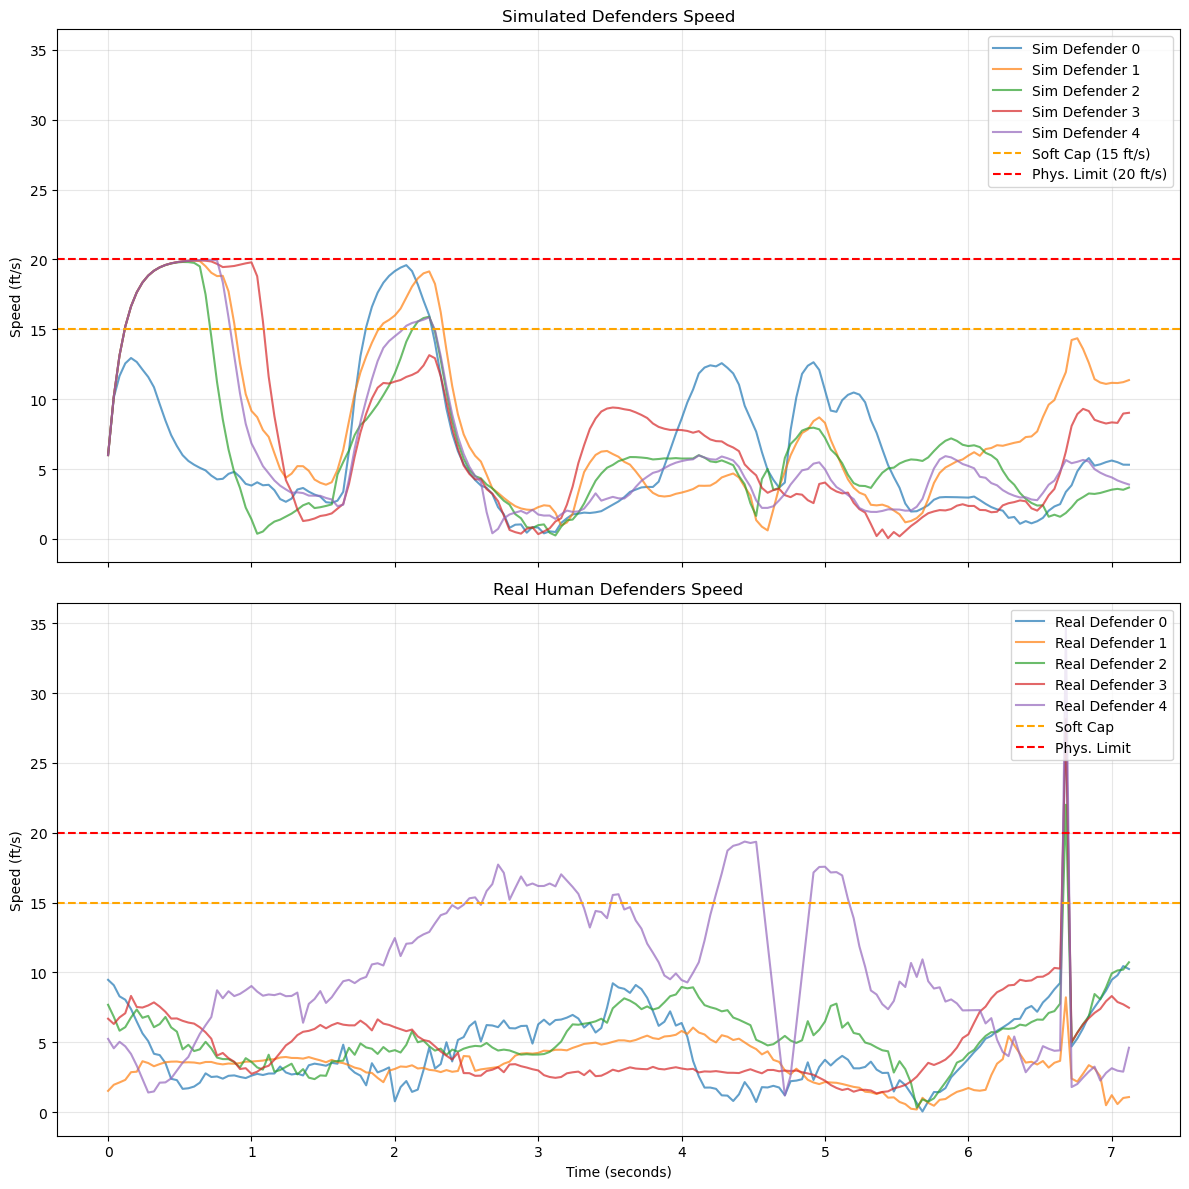

In [ ]:
plot_speed_analysis(smoothed_sim_def_traj, real_def_traj)

In [ ]:
# Run summary for 10 plays
summary_list = []
for i in range(df.shape[0]):
    play_data = df.iloc[i]
    summary_list.append(get_play_summary(play_data, best_params))

# Convert to DataFrame for easy viewing
summary_df = pd.DataFrame(summary_list)
print(summary_df)

KeyboardInterrupt: 

In [ ]:
get_global_report(summary_df)

      GLOBAL DEFENSIVE ANALYSIS REPORT    
Total Plays Analyzed:        110
Total Real Pressure:        24662.40
Total Sim Pressure:         25574.54
Total Pressure Prevented:   -623.14
---
GLOBAL EFFICIENCY GAIN:     -2.53%
---
Avg Gain per Play:          -3.86%
Median Gain per Play:       -2.15%
Consistency (Std Dev):      13.19%

TOP 3 DEFENSIVE LAPSES (Highest Sim Improvement):
 Play Index  Pressure Prevented Efficiency Gain (%)
         27               65.74               20.3%
         31               46.65               13.0%
         99               44.08               15.2%
